In [1]:
import numpy as np
import tensorflow as tf

import os
import zipfile

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

from scipy.interpolate import interp1d
from scipy import signal
from scipy.integrate import solve_ivp

from sklearn.model_selection import train_test_split

# Make sure interactive plotting is enabled
%matplotlib widget

# Function to load maximum displacement

In [2]:


def extract_x_s_max(thickness: str, f_: int, plot: bool = False) -> float:
    # thickness = "1mm6_12kg6"
    # thickness = "6mm4_12kg6"

    # Path to your zip file
    zip_file_path = r"C:\TRABAJO\CONICET\datasets\protection\\"
    zip_file_path += thickness + fr"\\F_{f_}_kN.zip"


    # Define the prefixes to organize files
    prefixes = ["flecha_chapa", "flecha_losa", "presion_chapa", "presion_losa"]


    # Extraction directory
    output_dir = r'C:\Users\joses\Mi unidad\TRABAJO\48_FG_protection\TRABAJO\fgp_optimizer\optimization_simple_plastic\full_simulation_data\iter1_mean_press'


    # Ensure the output directory exists
    os.makedirs(output_dir, exist_ok=True)

    # Extract and organize files
    with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
        for file_name in zip_ref.namelist():
            # Check if the file starts with any of the prefixes
            for prefix in prefixes:
                if file_name.startswith(prefix):
                    # Create the subfolder if it doesn't exist
                    subfolder_path = os.path.join(output_dir, prefix)
                    os.makedirs(subfolder_path, exist_ok=True)
                    
                    # Extract the file to the appropriate subfolder
                    source = zip_ref.open(file_name)
                    target_path = os.path.join(subfolder_path, os.path.basename(file_name))
                    with open(target_path, "wb") as target:
                        target.write(source.read())
                    break  # Stop checking other prefixes once a match is found


    # Extract nodos.txt
    with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
        source = zip_ref.open('nodos.txt')
        with open(os.path.join(output_dir, 'nodos.txt'), 'wb') as target:
            target.write(source.read())

    def load_multiple_records(file_path):
        with open(file_path, 'r') as file:
            lines = file.readlines()
        
        records = []
        current_record = []
        header = lines[0].strip()  # Assuming the first line is the header
        
        for line in lines:
            if line.strip() == header:
                if current_record:
                    records.append(np.array(current_record, dtype=float))
                    current_record = []
            else:
                current_record.append([float(value) for value in line.split()])
        
        if current_record:  # Add the last record if the file doesn't end with a header line
            records.append(np.array(current_record, dtype=float))
        
        return records


    # Folder path where the files are stored
    folder_path = output_dir
    folder_path_presion_losa = os.path.join(folder_path, 'presion_losa')  # N/cm2
    folder_path_presion_chapa = os.path.join(folder_path, 'presion_chapa') # MPa = N/mm2
    folder_path_flecha_losa = os.path.join(folder_path, 'flecha_losa')
    folder_path_flecha_chapa = os.path.join(folder_path, 'flecha_chapa')

    presion_losa_scale = 1/100

    # Dictionary to store the data for each node
    data_dicts = {}
    node_ids = []
    nodes = np.loadtxt(os.path.join(folder_path, 'nodos.txt'))[:, 1:]

    # Custom converters for handling invalid entries 
    def safe_convert(val): 
        try: 
            return float(val) 
        except ValueError: 
            return np.nan # or any default value

    converters = {1: safe_convert} # Apply safe_convert to the second column

    # Iterate over each file in the folder
    for filename in os.listdir(folder_path_presion_losa):
        if filename.startswith('presion_losa'):
            # Extract the node ID from the filename
            node_id = filename.split('node')[-1]
            node_ids.append(node_id)
            
            # Construct the full file path
            file_path_presion_losa = os.path.join(folder_path_presion_losa, filename)
            if filename.startswith('presion_losa_c'):
                file_path_flecha_losa = os.path.join(folder_path_flecha_losa, filename.replace('presion_losa_c_node', 'flecha_losa_node'))
            elif filename.startswith('presion_losa_f'):
                file_path_flecha_losa = os.path.join(folder_path_flecha_losa, filename.replace('presion_losa_f_node', 'flecha_losa_node'))

            # Load the data, skipping the first line
            data = load_multiple_records(file_path_presion_losa)
            
            # Load displacements and their time vector
            time_disp = np.loadtxt(file_path_flecha_losa, skiprows=1, converters=converters)

            # Store the time and pressure data in the dictionary under the node_id
            if node_id in data_dicts.keys():
                data_dicts[node_id] = {
                    'time': data[0][:, 0],
                    'pressure': data_dicts[node_id]['pressure'] - np.mean(np.array(data), axis=0)[:,1] * presion_losa_scale,
                    'displacement': np.interp(data[0][:, 0], time_disp[:, 0], time_disp[:, 1]), 
                    'coordinates': nodes[int(node_id)]
                }
            else:
                data_dicts[node_id] = {
                    'time': data[0][:, 0],
                    'pressure': - np.mean(np.array(data), axis=0)[:,1] * presion_losa_scale,
                    'displacement': np.interp(data[0][:, 0], time_disp[:, 0], time_disp[:, 1]), 
                    'coordinates': nodes[int(node_id)]
                }

    if plot:
        # Extraction of load pressure
        # Dictionary to store the data for each node
        data_dicts_load = {}
        node_ids_load = []
        # Iterate over each file in the folder
        for filename in os.listdir(folder_path_presion_chapa):
            if filename.startswith('presion_chapa_node'):
                # Extract the node ID from the filename
                node_id = filename.split('node')[-1]
                node_ids_load.append(node_id)
                
                # Construct the full file path
                file_path_presion_chapa = os.path.join(folder_path_presion_chapa, filename)
                file_path_flecha_chapa = os.path.join(folder_path_flecha_chapa, filename.replace('presion_chapa_node ', 'flecha_chapa_node'))
                
                # Load the data, skipping the first line
                data_load = load_multiple_records(file_path_presion_chapa)
                time_disp = np.loadtxt(file_path_flecha_chapa, skiprows=1, converters=converters)

                # Store the time and pressure data in the dictionary under the node_id
                data_dicts_load[node_id] = {
                    'time': data_load[0][:, 0],
                    'pressure': -np.mean(np.array(data_load), axis=0)[:,1],
                    'coordinates': nodes[int(node_id)],
                    'displacement': np.interp(data_load[0][:, 0], time_disp[:, 0], time_disp[:, 1]), 
                }

        fig1, ax1 = plt.subplots(3, 1, sharex='col')
        ax1 = ax1.flatten()

        n_rows = 150
        n_rows_load = 10*n_rows
        for node_id in node_ids_load:
            ax1[0].plot(data_dicts_load[node_id]['time'][:n_rows_load], data_dicts_load[node_id]['pressure'][:n_rows_load])
            ax1[0].set_ylabel('load pressure (MPa)')

        for node_id in node_ids:
            ax1[1].plot(data_dicts[node_id]['time'][:n_rows], data_dicts[node_id]['pressure'][:n_rows])
            ax1[1].set_ylabel('pressure (MPa)')
            ax1[2].plot(data_dicts[node_id]['time'][:n_rows], data_dicts[node_id]['displacement'][:n_rows])
            ax1[2].set_ylabel('displacement (mm)')
            ax1[2].set_xlabel('time (s)')
        plt.show()

    x_s_max_hf = 1e-3*np.max(np.abs(np.array([data_dicts[node_id]['displacement'] for node_id in node_ids]).ravel()))
    print(f"x_s_max_hf = {x_s_max_hf}  # m")
    return x_s_max_hf



# Analyze data

In [3]:
thickness = "1mm6_12kg6"
# thickness = "6mm4_12kg6"

f_arr = np.arange(5,200,5).astype(int)

x_s_max_1mm6_12kg6 = []

for f_ in f_arr:
    x_s_max_1mm6_12kg6.append(extract_x_s_max(thickness=thickness, f_=f_))

x_s_max_1mm6_12kg6 = np.array(x_s_max_1mm6_12kg6)

x_s_max_hf = 0.04632983131693144  # m
x_s_max_hf = 0.04564420705069872  # m
x_s_max_hf = 0.04091304495008589  # m
x_s_max_hf = 0.034374271406638575  # m
x_s_max_hf = 0.03352960968  # m
x_s_max_hf = 0.031747524288930164  # m
x_s_max_hf = 0.028961541256811073  # m
x_s_max_hf = 0.025954111140067744  # m
x_s_max_hf = 0.022643491715153858  # m
x_s_max_hf = 0.02078634638859562  # m
x_s_max_hf = 0.019208511193294222  # m
x_s_max_hf = 0.016480073939559955  # m
x_s_max_hf = 0.015741078223651832  # m
x_s_max_hf = 0.015939221382  # m
x_s_max_hf = 0.015246217710546513  # m
x_s_max_hf = 0.014822257997277637  # m
x_s_max_hf = 0.014107961568800311  # m
x_s_max_hf = 0.014980824510784876  # m
x_s_max_hf = 0.014901449181645592  # m
x_s_max_hf = 0.015346957422601287  # m
x_s_max_hf = 0.015412377502787442  # m
x_s_max_hf = 0.01652767550031999  # m
x_s_max_hf = 0.017274446311234315  # m
x_s_max_hf = 0.01799858861359217  # m
x_s_max_hf = 0.017224582773484504  # m
x_s_max_hf = 0.017308343887  # m
x_s_max_hf 

In [4]:
# thickness = "1mm6_12kg6"
thickness = "6mm4_12kg6"

x_s_max_6mm4_12kg6 = []

for f_ in f_arr:
    x_s_max_6mm4_12kg6.append(extract_x_s_max(thickness=thickness, f_=f_))

x_s_max_6mm4_12kg6 = np.array(x_s_max_6mm4_12kg6)

x_s_max_hf = 0.033891040960115755  # m
x_s_max_hf = 0.03026477812412816  # m
x_s_max_hf = 0.02911164672587489  # m
x_s_max_hf = 0.027915414910998734  # m
x_s_max_hf = 0.023135244209287822  # m
x_s_max_hf = 0.021142676536070864  # m
x_s_max_hf = 0.019767112485772904  # m
x_s_max_hf = 0.017109132919935877  # m
x_s_max_hf = 0.015451602966099048  # m
x_s_max_hf = 0.013694744152823434  # m
x_s_max_hf = 0.012423658283643342  # m
x_s_max_hf = 0.01176433242302031  # m
x_s_max_hf = 0.011463754646313612  # m
x_s_max_hf = 0.011052982403273988  # m
x_s_max_hf = 0.01021358019399324  # m
x_s_max_hf = 0.010609346247170375  # m
x_s_max_hf = 0.011609967169981332  # m
x_s_max_hf = 0.012230344093521537  # m
x_s_max_hf = 0.013044931061369251  # m
x_s_max_hf = 0.013864984596789691  # m
x_s_max_hf = 0.014203545578938192  # m
x_s_max_hf = 0.014565182702416916  # m
x_s_max_hf = 0.015277636568357116  # m
x_s_max_hf = 0.015712583269059274  # m
x_s_max_hf = 0.01589128780959004  # m
x_s_max_hf = 0.015939472277659

In [6]:
def plot_optimality(f_eq_optimized_1mm6, f_eq_optimized_6mm4, filename):
    x_s_max_1mm6_12kg6_optimized = x_s_max_1mm6_12kg6[np.argmin(np.abs(f_eq_optimized_1mm6 - f_arr))]
    x_s_max_6mm4_12kg6_optimized = x_s_max_6mm4_12kg6[np.argmin(np.abs(f_eq_optimized_1mm6 - f_arr))]

    f_eq_optimum_1mm6 = f_arr[np.argmin(np.abs(x_s_max_1mm6_12kg6))]
    f_eq_optimum_6mm4 = f_arr[np.argmin(np.abs(x_s_max_6mm4_12kg6))]
    x_s_max_1mm6_12kg6_optimum = np.min(np.abs(x_s_max_1mm6_12kg6))
    x_s_max_6mm4_12kg6_optimum = np.min(np.abs(x_s_max_6mm4_12kg6))

    fig = plt.figure(figsize=(5, 4))
    plt.tight_layout()
    plt.minorticks_on()
    plt.minorticks_on()
    plt.plot(f_arr, x_s_max_1mm6_12kg6, color='b', label='sheet thick. = 1.6 mm')
    plt.plot(f_arr, x_s_max_6mm4_12kg6, color='r', label='sheet thick. = 6.4 mm')
    plt.hlines(.018, 0, 200, colors=['k'], label='without protection')

    plt.vlines(f_eq_optimized_1mm6, 0, x_s_max_1mm6_12kg6_optimized, colors=['b'], linestyles=['dashed'], label='heurist. optimized')
    plt.vlines(f_eq_optimized_6mm4, 0, x_s_max_6mm4_12kg6_optimized, colors=['r'], linestyles=['dashed'], label='heurist. optimized')
    plt.vlines(f_eq_optimum_1mm6, 0, x_s_max_1mm6_12kg6_optimum, colors=['b'], linestyles=['dotted'], alpha=[0.5], label='brute force optimum')
    plt.vlines(f_eq_optimum_6mm4, 0, x_s_max_6mm4_12kg6_optimum, colors=['r'], linestyles=['dotted'], alpha=[0.5], label='brute force optimum')

    plt.xlabel(r'$f_{eq}$ (kN)')
    plt.ylabel(r'$\max_{t}{|x_s(t)|}$')
    plt.xlim([0, f_arr[-1]])
    plt.ylim([0, .05])
    plt.title('high-fidelity simulations')
    plt.legend()

    plt.hlines(x_s_max_1mm6_12kg6_optimized, 0, f_eq_optimized_1mm6, colors=['b'], linestyles=['dashed'], label='heurist. optimized')
    plt.hlines(x_s_max_6mm4_12kg6_optimized, 0, f_eq_optimized_6mm4, colors=['r'], linestyles=['dashed'], label='heurist. optimized')
    plt.hlines(x_s_max_1mm6_12kg6_optimum, 0, f_eq_optimum_1mm6, colors=['b'], linestyles=['dotted'], alpha=[0.5], label='brute force optimum')
    plt.hlines(x_s_max_6mm4_12kg6_optimum, 0, f_eq_optimum_6mm4, colors=['r'], linestyles=['dotted'], alpha=[0.5], label='brute force optimum')

    fig.savefig(filename, bbox_inches='tight')
    plt.show()

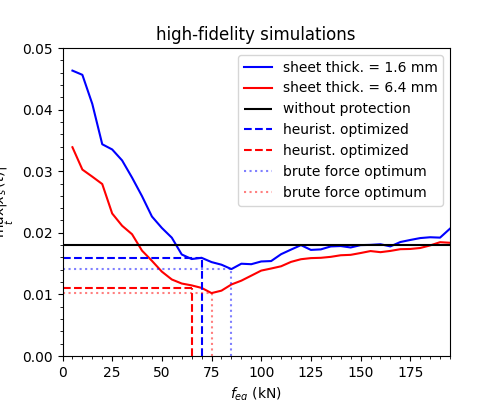

In [8]:
f_eq_optimized_1mm6 = 70.0
f_eq_optimized_6mm4 = 65.0
filename = 'optimality.pdf'
plot_optimality(f_eq_optimized_1mm6, f_eq_optimized_6mm4, filename)

# Work equivalence fs


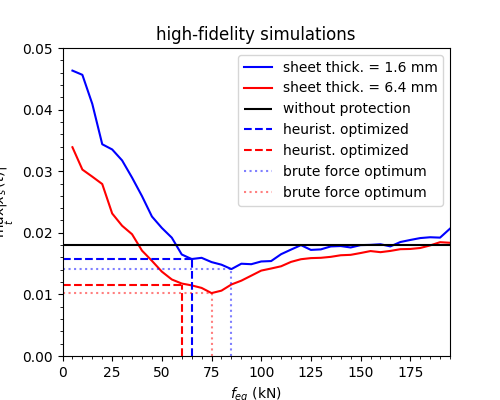

In [11]:
f_eq_optimized_1mm6 = 65.0
f_eq_optimized_6mm4 = 60.0
filename = 'optimality_work_eq_fs.pdf'
plot_optimality(f_eq_optimized_1mm6, f_eq_optimized_6mm4, filename)